In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("christophertreasure/nba-odds-data")

print("Path to dataset files:", path)

100%|██████████| 551k/551k [00:00<00:00, 51.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/christophertreasure/nba-odds-data/versions/3


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize

def win_probability(lead, t, mu, sigma):
    numerator = lead + (1 - t) * mu
    denominator = np.sqrt((1 - t) * sigma**2)
    return norm.cdf(numerator / denominator)

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("christophertreasure/nba-odds-data")
files = os.listdir(path)
print("Files:", files)

Using Colab cache for faster access to the 'nba-odds-data' dataset.
Files: ['.nfs0000000092fd941200000054', 'oddsData.csv']


In [ ]:
df_odds = pd.read_csv(path + '/oddsData.csv')  #odds replace FILENAME
print(df_odds.shape)
print(df_odds.columns.tolist())
print(df_odds[['team', 'home/visitor', 'opponent', 'score', 'opponentScore', 'spread']].head(20))

(37104, 12)
['date', 'season', 'team', 'home/visitor', 'opponent', 'score', 'opponentScore', 'moneyLine', 'opponentMoneyLine', 'total', 'spread', 'secondHalfTotal']
            team home/visitor      opponent  score  opponentScore  spread
0           Utah            @  Golden State    117             96     1.0
1      LA Lakers           vs       Houston     93             95     5.0
2        Houston            @     LA Lakers     95             93    -5.0
3    San Antonio           vs      Portland    106             97   -13.0
4       Portland            @   San Antonio     97            106    13.0
5   Golden State           vs          Utah     96            117    -1.0
6     New Jersey           vs       Chicago    112            103    -1.5
7         Dallas            @     Cleveland     92             74    -2.5
8      Cleveland           vs        Dallas     74             92     2.5
9        Seattle            @        Denver    103            120    11.5
10    Washington     

In [ ]:
print(sorted(df_odds['team'].unique()))

['Atlanta', 'Boston', 'Brooklyn', 'Charlotte', 'Chicago', 'Cleveland', 'Dallas', 'Denver', 'Detroit', 'Golden State', 'Houston', 'Indiana', 'LA Clippers', 'LA Lakers', 'Memphis', 'Miami', 'Milwaukee', 'Minnesota', 'New Jersey', 'New Orleans', 'New York', 'Oklahoma City', 'Orlando', 'Philadelphia', 'Phoenix', 'Portland', 'Sacramento', 'San Antonio', 'Seattle', 'Toronto', 'Utah', 'Washington']


In [ ]:
import kagglehub
path2 = kagglehub.dataset_download("joybiswas389/nba-matches-results-1949-2024")
df_nba = pd.read_csv(path2 + '/nba.csv')
print(sorted(df_nba['team1'].unique()))

100%|██████████| 1.68M/1.68M [00:00<00:00, 123MB/s]

Extracting files...


['76ers', 'Adecco ASVEL', 'Alba Berlin', 'Armani Jeans Milano', 'BC', 'Barry', 'Basket', 'Blackhawks', 'Bobcats', 'Bombers', 'Braves', 'Buckler Bologna', 'Bucks', 'Bullets', 'Bulls', 'CSKA', 'Canada', 'Capitols', 'Cavaliers', 'Celtics', 'China', 'Chuck', 'Clippers', 'Clutch City', 'Croatia', 'Deron', 'Durant', 'EA7 Emporio Armani Milano', 'East', 'Efes Pilsen', 'FC Barcelona Lassa', 'FC Barcelona Regal', 'Fenerbahce Ulker', 'Flamengo', 'Giannis', 'Grizzlies', 'Hawks', 'Heat', 'Home', 'Hornets', 'Isiah', 'Jason', 'Jazz', 'Jazz Blue', 'Jazz White', 'Kings', 'Knicks', 'Lakers', 'LeBron', 'Lottomatica Roma', 'MMT Estudiantes', 'Maccabi Elite', 'Magic', 'Mavericks', 'NBA D-League Select', 'Nationals', 'Nets', 'Nuggets', 'Olimpia Milano', 'Olympians', 'Pacers', 'Packers', 'Pallacanestro Varese', 'Pau', 'Pelicans', 'Perth Wildcats', 'Pistons', 'Raptors', 'Real Madrid', 'Redskins', 'Regal FC', 'Rockets', 'Rookies', 'Royals', 'Sophomores', 'Spain', 'Spurs', 'Stags', 'Stephen', 'Suns', 'SuperSon

In [ ]:
valid_teams = ['76ers', 'Bobcats', 'Bucks', 'Bulls', 'Cavaliers', 'Celtics',
               'Clippers', 'Grizzlies', 'Hawks', 'Heat', 'Hornets', 'Jazz',
               'Kings', 'Knicks', 'Lakers', 'Magic', 'Mavericks', 'Nets',
               'Nuggets', 'Pacers', 'Pelicans', 'Pistons', 'Raptors', 'Rockets',
               'Spurs', 'Suns', 'SuperSonics', 'Thunder', 'Timberwolves',
               'Trail Blazers', 'Warriors', 'Wizards']

df_nba_filtered = df_nba[df_nba['team1'].isin(valid_teams) & df_nba['team2'].isin(valid_teams)]
print(f'Filtered rows: {len(df_nba_filtered)}')
print(df_nba_filtered['team1'].unique())

Filtered rows: 65285
['Warriors' 'Hawks' 'Pistons' 'Celtics' 'Knicks' 'Nuggets' 'Lakers'
 '76ers' 'Bulls' 'Rockets' 'SuperSonics' 'Bucks' 'Suns' 'Trail Blazers'
 'Cavaliers' 'Kings' 'Jazz' 'Pacers' 'Spurs' 'Nets' 'Clippers' 'Mavericks'
 'Hornets' 'Heat' 'Magic' 'Timberwolves' 'Raptors' 'Grizzlies' 'Wizards'
 'Bobcats' 'Thunder' 'Pelicans']


In [ ]:
team_mapping = {
    'Atlanta': 'Hawks',
    'Boston': 'Celtics',
    'Brooklyn': 'Nets',
    'Charlotte': 'Bobcats',
    'Chicago': 'Bulls',
    'Cleveland': 'Cavaliers',
    'Dallas': 'Mavericks',
    'Denver': 'Nuggets',
    'Detroit': 'Pistons',
    'Golden State': 'Warriors',
    'Houston': 'Rockets',
    'Indiana': 'Pacers',
    'LA Clippers': 'Clippers',
    'LA Lakers': 'Lakers',
    'Memphis': 'Grizzlies',
    'Miami': 'Heat',
    'Milwaukee': 'Bucks',
    'Minnesota': 'Timberwolves',
    'New Jersey': 'Nets',
    'New Orleans': 'Pelicans',
    'New York': 'Knicks',
    'Oklahoma City': 'Thunder',
    'Orlando': 'Magic',
    'Philadelphia': '76ers',
    'Phoenix': 'Suns',
    'Portland': 'Trail Blazers',
    'Sacramento': 'Kings',
    'San Antonio': 'Spurs',
    'Seattle': 'SuperSonics',
    'Toronto': 'Raptors',
    'Utah': 'Jazz',
    'Washington': 'Wizards'
}

In [ ]:
# Filter to home games only
df_home = df_odds[df_odds['home/visitor'] == 'vs'].copy()

# Apply team name mapping
df_home['team_short'] = df_home['team'].map(team_mapping)
df_home['opponent_short'] = df_home['opponent'].map(team_mapping)

# Flip spread so positive = home team favored
df_home['mu'] = -df_home['spread']

print(df_home[['team_short', 'opponent_short', 'score', 'opponentScore', 'mu']].head(10))
print(f'\nRows: {len(df_home)}')

   team_short opponent_short  score  opponentScore    mu
1      Lakers        Rockets     93             95  -5.0
3       Spurs  Trail Blazers    106             97  13.0
5    Warriors           Jazz     96            117   1.0
6        Nets          Bulls    112            103   1.5
8   Cavaliers      Mavericks     74             92  -2.5
12      Magic          Bucks    102             83   6.5
16    Raptors          76ers    106             97   6.5
17   Pelicans          Kings    104             90   9.5
18  Grizzlies          Spurs    101            104  -6.5
19    Nuggets    SuperSonics    120            103  11.5

Rows: 18649


In [ ]:
df_merged = df_home.merge(
    df_nba_filtered,
    left_on=['team_short', 'opponent_short', 'score', 'opponentScore'],
    right_on=['team1', 'team2', 'team1_score', 'team2_score'],
    how='inner'
)

print(f'Merged rows: {len(df_merged)}')
print(df_merged.head(5))

Merged rows: 18078
         date  season          team home/visitor  opponent  score  \
0  2007-10-30    2008     LA Lakers           vs   Houston     93   
1  2007-10-30    2008   San Antonio           vs  Portland    106   
2  2007-10-30    2008  Golden State           vs      Utah     96   
3  2007-10-31    2008    New Jersey           vs   Chicago    112   
4  2007-10-31    2008     Cleveland           vs    Dallas     74   

   opponentScore  moneyLine  opponentMoneyLine  total  ...  period_Q5_team2  \
0             95      190.0             -230.0  199.0  ...                0   
1             97    -1400.0              900.0  189.5  ...                0   
2            117     -120.0              100.0  212.0  ...                0   
3            103     -125.0              105.0  186.0  ...                7   
4             92      120.0             -140.0  184.0  ...                0   

   period_Q6_team1 period_Q6_team2 period_Q7_team1  period_Q7_team2  \
0                0  

In [ ]:
print(df_home[df_home['team_short'].isna()]['team'].unique())
print(df_home[df_home['opponent_short'].isna()]['opponent'].unique())

[]
[]


In [ ]:
print(f'Home games in odds dataset: {len(df_home)}')
print(f'Games in filtered NBA dataset: {len(df_nba_filtered)}')

Home games in odds dataset: 18649
Games in filtered NBA dataset: 65285


In [ ]:
est_data = []

for idx, row in df_merged.iterrows():
    home_Q1 = row['period_Q1_team1']
    away_Q1 = row['period_Q1_team2']
    home_Q2 = home_Q1 + row['period_Q2_team1']
    away_Q2 = away_Q1 + row['period_Q2_team2']
    home_Q3 = home_Q2 + row['period_Q3_team1']
    away_Q3 = away_Q2 + row['period_Q3_team2']

    home_win = 1 - row['verdict']
    mu = row['mu']

    for lead, t in [(home_Q1 - away_Q1, 0.25),
                    (home_Q2 - away_Q2, 0.50),
                    (home_Q3 - away_Q3, 0.75)]:
        est_data.append({
            'lead': lead,
            't': t,
            'mu': mu,
            'home_win': home_win
        })

est_df = pd.DataFrame(est_data)
print(f'Total observations: {len(est_df)}')
print(est_df.head(9))

Total observations: 54234
   lead     t    mu  home_win
0     9  0.25  -5.0         0
1     0  0.50  -5.0         0
2    -8  0.75  -5.0         0
3     3  0.25  13.0         1
4    10  0.50  13.0         1
5     4  0.75  13.0         1
6     2  0.25   1.0         0
7   -11  0.50   1.0         0
8   -14  0.75   1.0         0


In [ ]:
def negative_log_likelihood_sigma_only(sigma, data):
    if sigma <= 0:
        return 1e10

    probs = win_probability(
        data['lead'].values,
        data['t'].values,
        data['mu'].values,  # per-game mu from spread
        sigma
    )

    likelihood = np.where(data['home_win'].values == 1, probs, 1 - probs)
    likelihood = np.clip(likelihood, 1e-10, 1 - 1e-10)
    return -np.sum(np.log(likelihood))

from scipy.optimize import minimize_scalar

result = minimize_scalar(
    negative_log_likelihood_sigma_only,
    bounds=(1, 50),
    method='bounded',
    args=(est_df,)
)

sigma_hat = result.x
print(f'Sigma with variable mu: {sigma_hat:.2f}')
print(f'Optimization successful: {result.success}')

Sigma with variable mu: 16.88
Optimization successful: True


In [ ]:
print(df_merged['date'].head(10))

0    2007-10-30
1    2007-10-30
2    2007-10-30
3    2007-10-31
4    2007-10-31
5    2007-10-31
6    2007-10-31
7    2007-10-31
8    2007-10-31
9    2007-10-31
Name: date, dtype: object


In [ ]:
df_merged['date'] = pd.to_datetime(df_merged['date'])

df_train = df_merged[df_merged['date'].dt.year != 2022]
df_test = df_merged[df_merged['date'].dt.year == 2022]

print(f'Training games: {len(df_train)}')
print(f'Test games: {len(df_test)}')

Training games: 16869
Test games: 1209


In [ ]:
# Build training estimation dataset
est_train = []

for idx, row in df_train.iterrows():
    home_Q1 = row['period_Q1_team1']
    away_Q1 = row['period_Q1_team2']
    home_Q2 = home_Q1 + row['period_Q2_team1']
    away_Q2 = away_Q1 + row['period_Q2_team2']
    home_Q3 = home_Q2 + row['period_Q3_team1']
    away_Q3 = away_Q2 + row['period_Q3_team2']

    home_win = 1 - row['verdict']
    mu = row['mu']

    for lead, t in [(home_Q1 - away_Q1, 0.25),
                    (home_Q2 - away_Q2, 0.50),
                    (home_Q3 - away_Q3, 0.75)]:
        est_train.append({
            'lead': lead,
            't': t,
            'mu': mu,
            'home_win': home_win
        })

est_train_df = pd.DataFrame(est_train)

# Refit sigma on training data only
result_train = minimize_scalar(
    negative_log_likelihood_sigma_only,
    bounds=(1, 50),
    method='bounded',
    args=(est_train_df,)
)

sigma_new = result_train.x
print(f'Sigma (trained without 2022): {sigma_new:.2f}')

Sigma (trained without 2022): 16.74


In [ ]:
# Build test estimation dataset at Q3 only
test_data = []

for idx, row in df_test.iterrows():
    home_Q1 = row['period_Q1_team1']
    away_Q1 = row['period_Q1_team2']
    home_Q2 = home_Q1 + row['period_Q2_team1']
    away_Q2 = away_Q1 + row['period_Q2_team2']
    home_Q3 = home_Q2 + row['period_Q3_team1']
    away_Q3 = away_Q2 + row['period_Q3_team2']

    test_data.append({
        'lead': home_Q3 - away_Q3,
        't': 0.75,
        'mu': row['mu'],
        'home_win': 1 - row['verdict']
    })

test_df = pd.DataFrame(test_data)

# Model 1: fixed mu = 4.94, sigma = 16.90 (Stern style)
probs_fixed = win_probability(test_df['lead'].values, test_df['t'].values, 4.94, 16.90)

# Model 2: variable mu from spread, sigma = 16.74
probs_variable = win_probability(test_df['lead'].values, test_df['t'].values, test_df['mu'].values, sigma_new)

# Brier scores
brier_fixed = np.mean((probs_fixed - test_df['home_win'].values)**2)
brier_variable = np.mean((probs_variable - test_df['home_win'].values)**2)

print(f'Brier score - Fixed mu: {brier_fixed:.4f}')
print(f'Brier score - Variable mu: {brier_variable:.4f}')
print(f'Improvement: {((brier_fixed - brier_variable)/brier_fixed)*100:.2f}%')

Brier score - Fixed mu: 0.1366
Brier score - Variable mu: 0.1333
Improvement: 2.42%


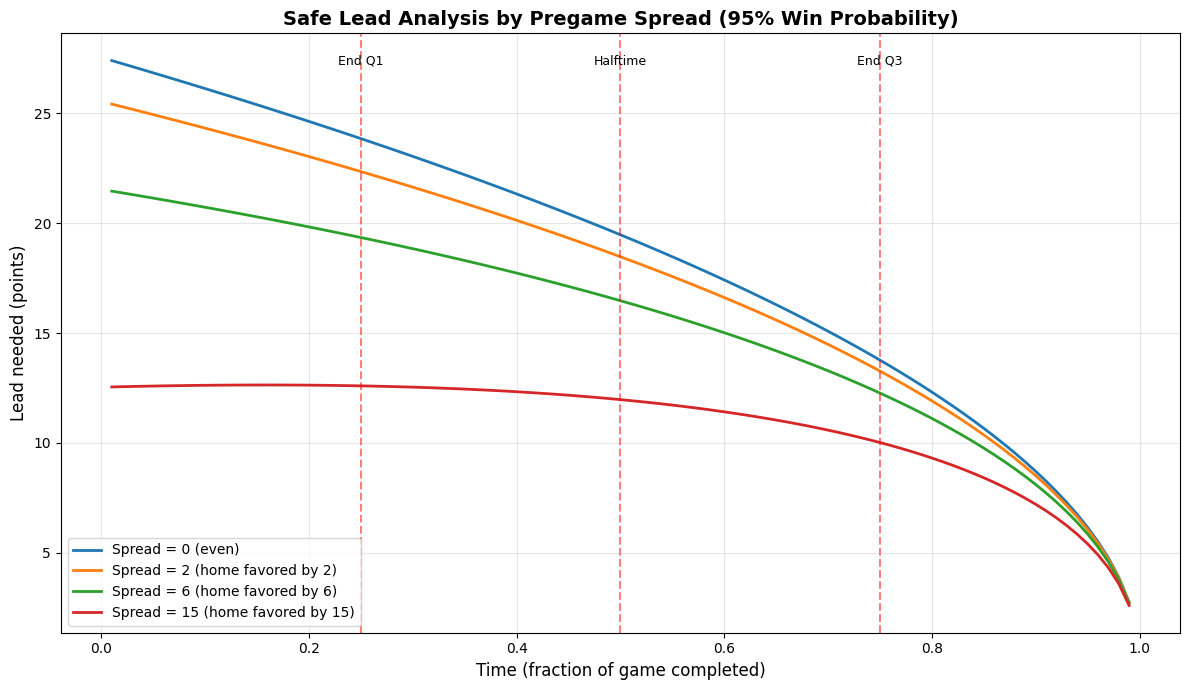

In [ ]:
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

sigma_final = 16.74

def find_lead_for_probability_mu(target_prob, t, mu, sigma):
    def equation(lead):
        return win_probability(lead, t, mu, sigma) - target_prob
    solution = fsolve(equation, 10)
    return solution[0]

time_points = np.linspace(0.01, 0.99, 99)
spreads = [0, 2, 6, 15]
target_prob = 0.95

plt.figure(figsize=(12, 7))

for mu in spreads:
    leads = [find_lead_for_probability_mu(target_prob, t, mu, sigma_final) for t in time_points]
    label = f'Spread = {mu} ({"even" if mu == 0 else "home favored by " + str(mu)})'
    plt.plot(time_points, leads, linewidth=2, label=label)

plt.xlabel('Time (fraction of game completed)', fontsize=12)
plt.ylabel('Lead needed (points)', fontsize=12)
plt.title('Safe Lead Analysis by Pregame Spread (95% Win Probability)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

for q, label in [(0.25, 'End Q1'), (0.50, 'Halftime'), (0.75, 'End Q3')]:
    plt.axvline(q, color='red', linestyle='--', alpha=0.5)
    plt.text(q, plt.ylim()[1]*0.95, label, ha='center', fontsize=9)

plt.tight_layout()
plt.show()

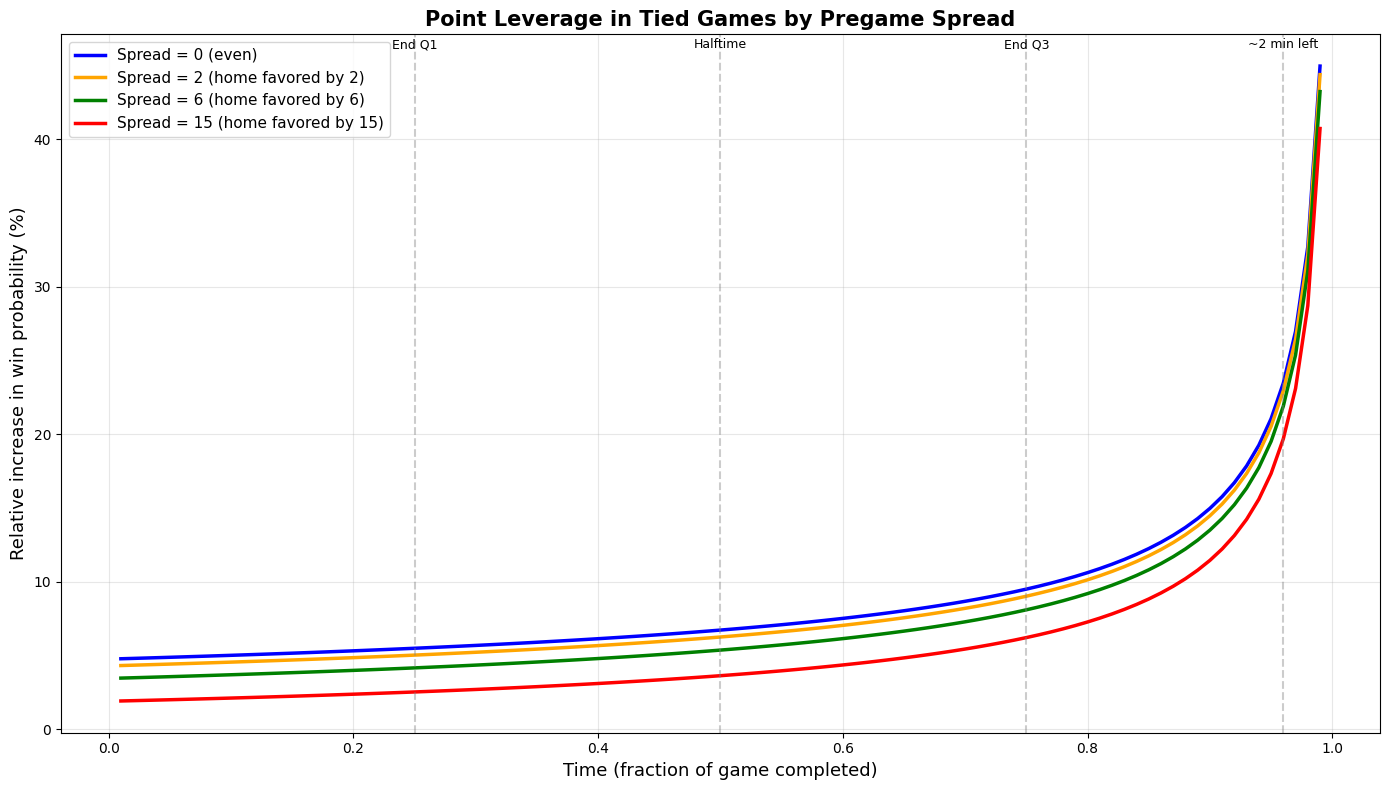

In [ ]:
time_points = np.linspace(0.01, 0.99, 99)
spreads = [0, 2, 6, 15]

plt.figure(figsize=(14, 8))

colors = ['blue', 'orange', 'green', 'red']
for mu, color in zip(spreads, colors):
    leverage = []
    for t in time_points:
        prob_before = win_probability(0, t, mu, sigma_final)
        prob_after = win_probability(1, t, mu, sigma_final)
        if prob_before > 0:
            rel_increase = ((prob_after - prob_before) / prob_before) * 100
        else:
            rel_increase = 0
        leverage.append(rel_increase)

    label = f'Spread = {mu} ({"even" if mu == 0 else "home favored by " + str(mu)})'
    plt.plot(time_points, leverage, linewidth=2.5, color=color, label=label)

plt.xlabel('Time (fraction of game completed)', fontsize=13)
plt.ylabel('Relative increase in win probability (%)', fontsize=13)
plt.title('Point Leverage in Tied Games by Pregame Spread', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

for q, label in [(0.25, 'End Q1'), (0.50, 'Halftime'), (0.75, 'End Q3'), (0.96, '~2 min left')]:
    plt.axvline(q, color='gray', linestyle='--', alpha=0.4)
    plt.text(q, plt.ylim()[1]*0.98, label, ha='center', fontsize=9)

plt.tight_layout()
plt.show()

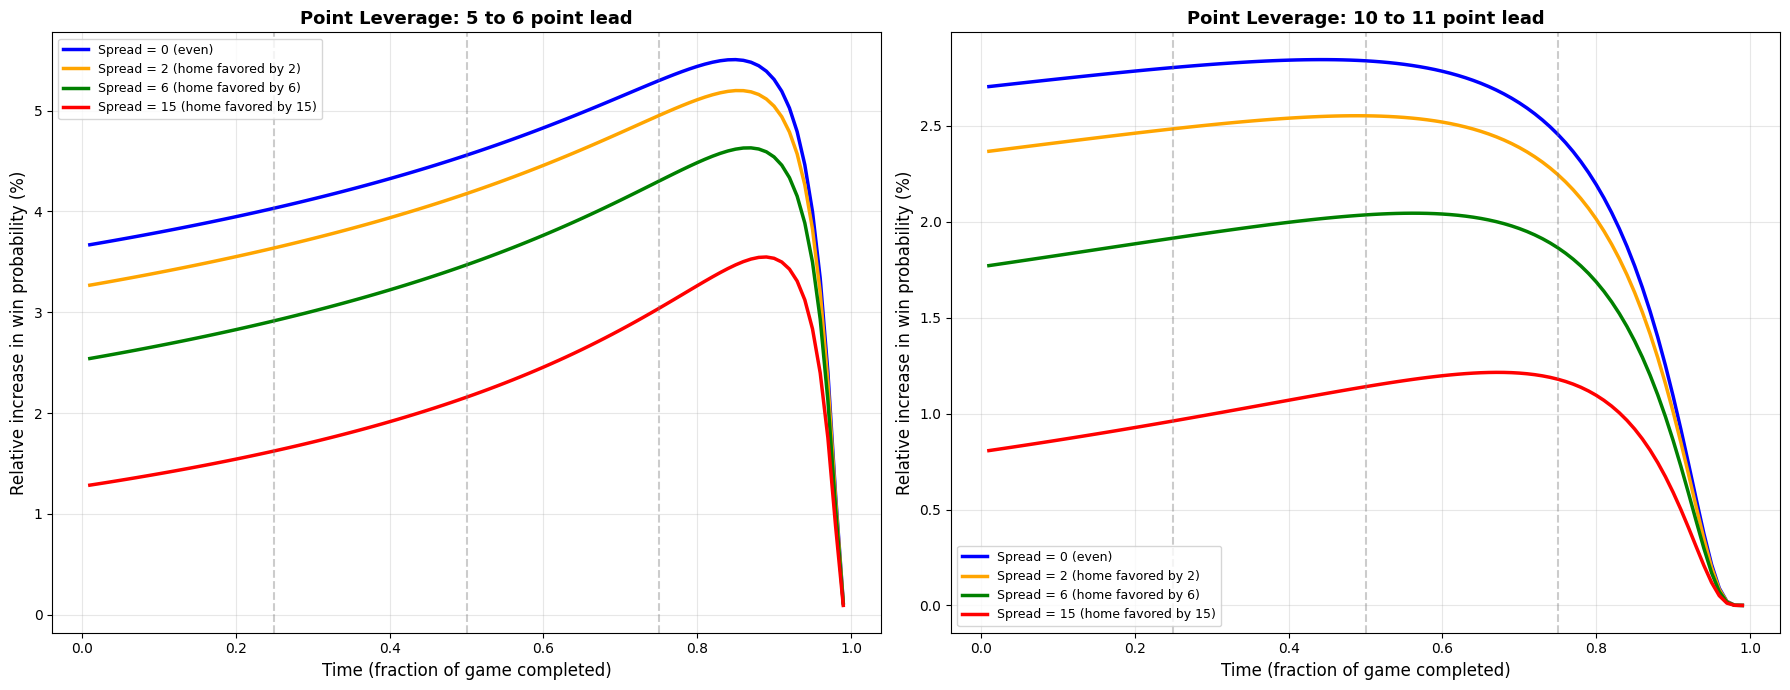

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scenarios = [(5, '5 to 6 point lead'), (10, '10 to 11 point lead')]
colors = ['blue', 'orange', 'green', 'red']

for ax, (starting_lead, title) in zip(axes, scenarios):
    for mu, color in zip(spreads, colors):
        leverage = []
        for t in time_points:
            prob_before = win_probability(starting_lead, t, mu, sigma_final)
            prob_after = win_probability(starting_lead + 1, t, mu, sigma_final)
            if prob_before > 0:
                rel_increase = ((prob_after - prob_before) / prob_before) * 100
            else:
                rel_increase = 0
            leverage.append(rel_increase)

        label = f'Spread = {mu} ({"even" if mu == 0 else "home favored by " + str(mu)})'
        ax.plot(time_points, leverage, linewidth=2.5, color=color, label=label)

    ax.set_xlabel('Time (fraction of game completed)', fontsize=12)
    ax.set_ylabel('Relative increase in win probability (%)', fontsize=12)
    ax.set_title(f'Point Leverage: {title}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    for q in [0.25, 0.50, 0.75]:
        ax.axvline(q, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

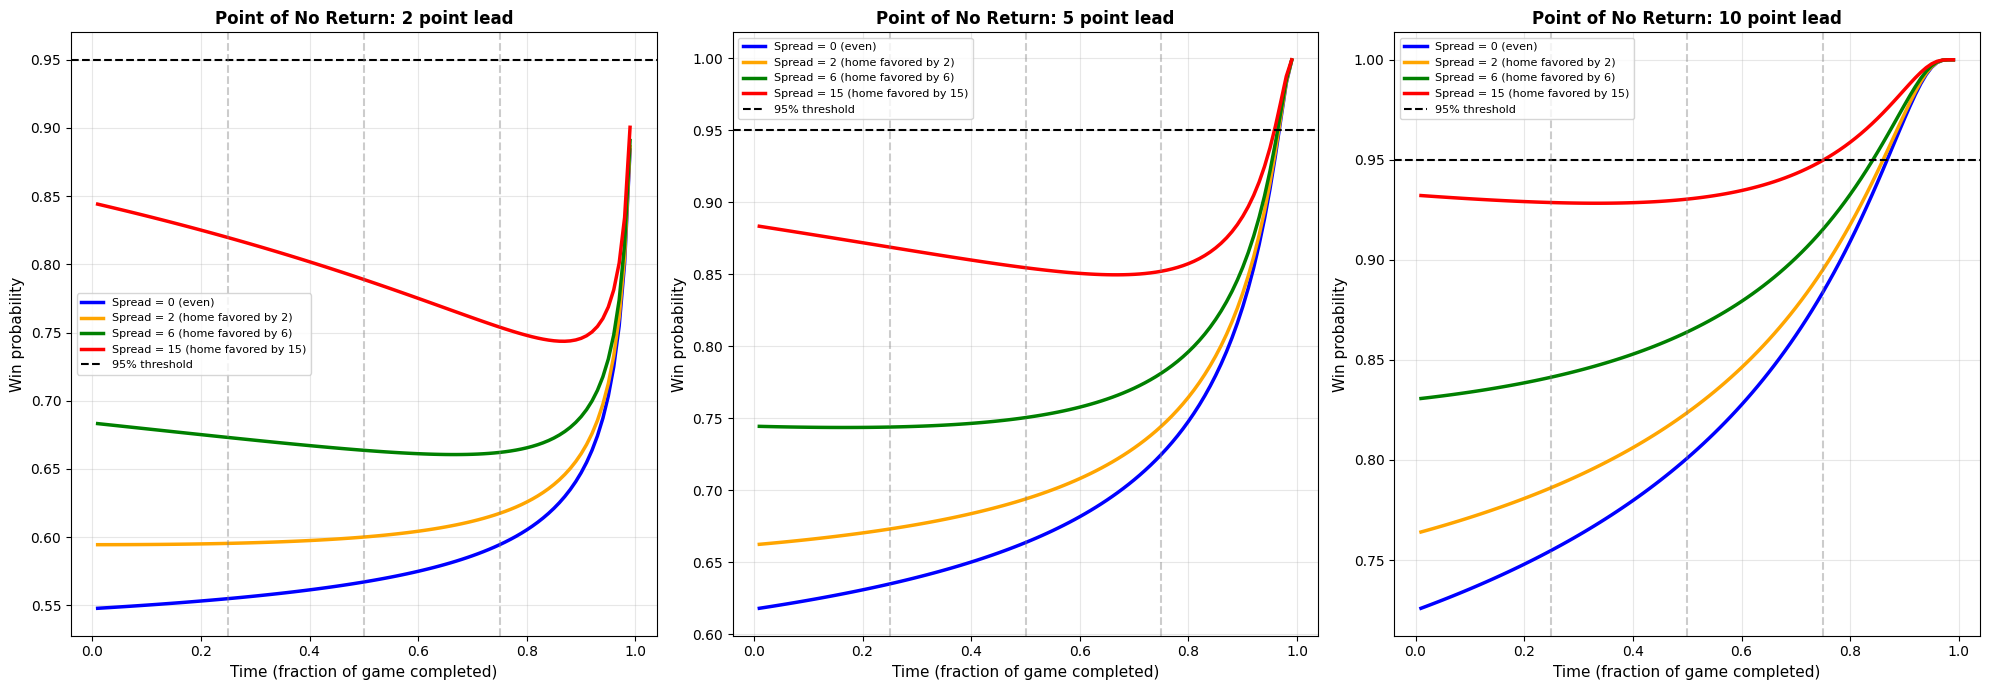

In [ ]:
from scipy.optimize import brentq

spreads = [0, 2, 6, 15]
leads = [2, 5, 10]
colors = ['blue', 'orange', 'green', 'red']
target_prob = 0.95

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, lead in zip(axes, leads):
    for mu, color in zip(spreads, colors):
        probs = [win_probability(lead, t, mu, sigma_final) for t in time_points]
        label = f'Spread = {mu} ({"even" if mu == 0 else "home favored by " + str(mu)})'
        ax.plot(time_points, probs, linewidth=2.5, color=color, label=label)

    ax.axhline(0.95, color='black', linestyle='--', linewidth=1.5, label='95% threshold')
    ax.set_xlabel('Time (fraction of game completed)', fontsize=11)
    ax.set_ylabel('Win probability', fontsize=11)
    ax.set_title(f'Point of No Return: {lead} point lead', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    for q in [0.25, 0.50, 0.75]:
        ax.axvline(q, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
time_points = np.linspace(0.01, 0.99, 99)
mu = 0
lead = 0

leverage_all = []
for t in time_points:
    prob_before = win_probability(lead, t, mu, sigma_final)
    prob_after = win_probability(lead + 1, t, mu, sigma_final)
    if prob_before > 0:
        rel_increase = ((prob_after - prob_before) / prob_before) * 100
    else:
        rel_increase = 0
    leverage_all.append(rel_increase)

leverage_all = np.array(leverage_all)

# Q3: t = 0.5 to 0.75
q3_mask = (time_points >= 0.5) & (time_points < 0.75)
# Q4: t = 0.75 to 1.0
q4_mask = (time_points >= 0.75) & (time_points < 1.0)

q3_avg = np.mean(leverage_all[q3_mask])
q4_avg = np.mean(leverage_all[q4_mask])

print(f'Average leverage Q3 (tied, even game): {q3_avg:.2f}%')
print(f'Average leverage Q4 (tied, even game): {q4_avg:.2f}%')
print(f'Q4 is {q4_avg/q3_avg:.2f}x more valuable than Q3')

Average leverage Q3 (tied, even game): 7.83%
Average leverage Q4 (tied, even game): 16.23%
Q4 is 2.07x more valuable than Q3


In [ ]:
time_points = np.linspace(0.01, 0.99, 99)
mu = 0
lead = 10

leverage_all = []
for t in time_points:
    prob_before = win_probability(lead, t, mu, sigma_final)
    prob_after = win_probability(lead + 1, t, mu, sigma_final)
    if prob_before > 0:
        rel_increase = ((prob_after - prob_before) / prob_before) * 100
    else:
        rel_increase = 0
    leverage_all.append(rel_increase)

leverage_all = np.array(leverage_all)

# Q3: t = 0.5 to 0.75
q3_mask = (time_points >= 0.5) & (time_points < 0.75)
# Q4: t = 0.75 to 1.0
q4_mask = (time_points >= 0.75) & (time_points < 1.0)

q3_avg = np.mean(leverage_all[q3_mask])
q4_avg = np.mean(leverage_all[q4_mask])

print(f'Average leverage Q3 (tied, even game): {q3_avg:.2f}%')
print(f'Average leverage Q4 (tied, even game): {q4_avg:.2f}%')
print(f'Q4 is {q4_avg/q3_avg:.2f}x more valuable than Q3')

Average leverage Q3 (tied, even game): 2.73%
Average leverage Q4 (tied, even game): 1.34%
Q4 is 0.49x more valuable than Q3


In [ ]:
scenarios = [(0, 0), (0, 5), (0, 10), (10, 0), (10, 5), (10, 10)]

for lead, mu in scenarios:
    leverage_all = []
    for t in time_points:
        prob_before = win_probability(lead, t, mu, sigma_final)
        prob_after = win_probability(lead + 1, t, mu, sigma_final)
        if prob_before > 0:
            rel_increase = ((prob_after - prob_before) / prob_before) * 100
        else:
            rel_increase = 0
        leverage_all.append(rel_increase)

    leverage_all = np.array(leverage_all)
    q3_mask = (time_points >= 0.5) & (time_points < 0.75)
    q4_mask = (time_points >= 0.75) & (time_points < 1.0)

    q3_avg = np.mean(leverage_all[q3_mask])
    q4_avg = np.mean(leverage_all[q4_mask])

    print(f'Lead={lead}, Spread={mu}: Q3={q3_avg:.2f}%, Q4={q4_avg:.2f}%, ratio={q4_avg/q3_avg:.2f}x')

Lead=0, Spread=0: Q3=7.83%, Q4=16.23%, ratio=2.07x
Lead=0, Spread=5: Q3=6.67%, Q4=14.99%, ratio=2.25x
Lead=0, Spread=10: Q3=5.61%, Q4=13.81%, ratio=2.46x
Lead=10, Spread=0: Q3=2.73%, Q4=1.34%, ratio=0.49x
Lead=10, Spread=5: Q3=2.12%, Q4=1.09%, ratio=0.51x
Lead=10, Spread=10: Q3=1.61%, Q4=0.87%, ratio=0.54x


In [ ]:
# Count games per spread scenario in the merged dataset
bins = [(-float('inf'), 1), (1, 4), (4, 9), (9, float('inf'))]
labels = ['Spread = 0 (even, 0-1)', 'Spread = 2 (1-4)', 'Spread = 6 (4-9)', 'Spread = 15 (9+)']

for (low, high), label in zip(bins, labels):
    count = df_merged[(df_merged['mu'] > low) & (df_merged['mu'] <= high)].shape[0]
    print(f'{label}: {count} games')

print(f'\nTotal games: {len(df_merged)}')

Spread = 0 (even, 0-1): 6627 games
Spread = 2 (1-4): 3129 games
Spread = 6 (4-9): 5331 games
Spread = 15 (9+): 2991 games

Total games: 18078


In [ ]:
seasons_to_test = [2018, 2019, 2020, 2021, 2022]
results = []

for test_year in seasons_to_test:
    # Split data
    train = df_merged[df_merged['date'].dt.year != test_year]
    test = df_merged[df_merged['date'].dt.year == test_year]

    # Build training estimation dataset
    est_train = []
    for idx, row in train.iterrows():
        home_Q1 = row['period_Q1_team1']
        away_Q1 = row['period_Q1_team2']
        home_Q2 = home_Q1 + row['period_Q2_team1']
        away_Q2 = away_Q1 + row['period_Q2_team2']
        home_Q3 = home_Q2 + row['period_Q3_team1']
        away_Q3 = away_Q2 + row['period_Q3_team2']
        home_win = 1 - row['verdict']
        mu = row['mu']
        for lead, t in [(home_Q1-away_Q1, 0.25),
                        (home_Q2-away_Q2, 0.50),
                        (home_Q3-away_Q3, 0.75)]:
            est_train.append({'lead': lead, 't': t, 'mu': mu, 'home_win': home_win})

    est_train_df = pd.DataFrame(est_train)

    # Fit sigma on training data
    result = minimize_scalar(
        negative_log_likelihood_sigma_only,
        bounds=(1, 50),
        method='bounded',
        args=(est_train_df,)
    )
    sigma_fitted = result.x

    # Build test dataset at Q3
    test_data = []
    for idx, row in test.iterrows():
        home_Q3 = row['period_Q1_team1'] + row['period_Q2_team1'] + row['period_Q3_team1']
        away_Q3 = row['period_Q1_team2'] + row['period_Q2_team2'] + row['period_Q3_team2']
        test_data.append({
            'lead': home_Q3 - away_Q3,
            't': 0.75,
            'mu': row['mu'],
            'home_win': 1 - row['verdict']
        })

    test_df_year = pd.DataFrame(test_data)

    # Brier scores
    probs_fixed = win_probability(test_df_year['lead'].values, test_df_year['t'].values, 4.94, 16.90)
    probs_variable = win_probability(test_df_year['lead'].values, test_df_year['t'].values, test_df_year['mu'].values, sigma_fitted)

    brier_fixed = np.mean((probs_fixed - test_df_year['home_win'].values)**2)
    brier_variable = np.mean((probs_variable - test_df_year['home_win'].values)**2)
    improvement = ((brier_fixed - brier_variable) / brier_fixed) * 100

    results.append({
        'Season': test_year,
        'Games': len(test_df_year),
        'Brier_Fixed': round(brier_fixed, 4),
        'Brier_Variable': round(brier_variable, 4),
        'Improvement': round(improvement, 2)
    })
    print(f'{test_year}: Fixed={brier_fixed:.4f}, Variable={brier_variable:.4f}, Improvement={improvement:.2f}%')

results_df = pd.DataFrame(results)
print('\nSummary Table:')
print(results_df)
print(f'\nMean improvement: {results_df["Improvement"].mean():.2f}%')
print(f'Std improvement: {results_df["Improvement"].std():.2f}%')

2018: Fixed=0.1202, Variable=0.1173, Improvement=2.36%
2019: Fixed=0.1281, Variable=0.1229, Improvement=4.07%
2020: Fixed=0.1304, Variable=0.1268, Improvement=2.69%
2021: Fixed=0.1284, Variable=0.1240, Improvement=3.44%
2022: Fixed=0.1366, Variable=0.1333, Improvement=2.42%

Summary Table:
   Season  Games  Brier_Fixed  Brier_Variable  Improvement
0    2018   1187       0.1202          0.1173         2.36
1    2019   1139       0.1281          0.1229         4.07
2    2020    603       0.1304          0.1268         2.69
3    2021   1482       0.1284          0.1240         3.44
4    2022   1209       0.1366          0.1333         2.42

Mean improvement: 3.00%
Std improvement: 0.74%


In [ ]:
avg_games = np.mean([1187, 1139, 603, 1482, 1209])
games_flipped = avg_games * 0.03
print(f'Average games per season: {avg_games:.0f}')
print(f'Approximate games flipped: {games_flipped:.0f}')

Average games per season: 1124
Approximate games flipped: 34
